# Simulação de Fila M/M/1

**Parâmetros:** λ = 9 clientes/s · μ = 10 clientes/s · ρ = λ/μ = 0,9

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho}, \quad \rho = \frac{\lambda}{\mu}$$

In [26]:
import time
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import pandas as pd
from scipy import stats as sp_stats

# ── Parâmetros ────────────────────────────────────────────────────────────────
LAM = 9.0  # taxa de chegada  λ
MU = 10.0  # taxa de serviço  μ
Z95 = 1.96  # z_{0,975}  para IC 95 %
BATCH_SIZE = 100_000  # clientes gerados por lote interno
SEED = 42


def theoretical_mean(lam=LAM, mu=MU):
    """E[X] = ρ·(1/μ)/(1−ρ)"""
    rho = lam / mu
    return rho / (mu * (1.0 - rho))


print(f"E[X] teórico = {theoretical_mean():.6f} s")

E[X] teórico = 0.900000 s


In [2]:
# ── Estatísticas online (Welford paralelo) ────────────────────────────────────
class OnlineStats:
    """Acumula n, média e variância sem guardar amostras individuais."""

    __slots__ = ("n", "_mean", "_M2")

    def __init__(self):
        self.n, self._mean, self._M2 = 0, 0.0, 0.0

    def add_batch(self, xs: np.ndarray):
        n_b = len(xs)
        mean_b = float(xs.mean())
        M2_b = float(((xs - mean_b) ** 2).sum())
        if self.n == 0:
            self.n, self._mean, self._M2 = n_b, mean_b, M2_b
        else:
            n_new = self.n + n_b
            delta = mean_b - self._mean
            self._mean += delta * n_b / n_new
            self._M2 += M2_b + delta**2 * self.n * n_b / n_new
            self.n = n_new

    @property
    def mean(self):
        return self._mean

    @property
    def variance(self):
        return self._M2 / (self.n - 1) if self.n > 1 else float("inf")

    @property
    def half_width(self):
        """H = 1,96 · s / √n"""
        return Z95 * (self.variance / self.n) ** 0.5 if self.n > 1 else float("inf")


# ── Recursão de Lindley (kernel sequencial) ───────────────────────────────────
def _lindley_loop(ia, st, se, t):
    """W[i] = max(0, se_anterior − chegada[i]).  Retorna (waits, se, t)."""
    n = len(ia)
    waiting = [0.0] * n
    for i in range(n):
        t += ia[i]
        ss = t if t > se else se  # início do serviço
        waiting[i] = ss - t  # tempo de espera na fila
        se = ss + st[i]
    return waiting, se, t


# ── Simulador M/M/1 ───────────────────────────────────────────────────────────
class MM1Queue:
    def __init__(self, lam=LAM, mu=MU, seed=None):
        self.lam = lam
        self.mu = mu
        self.rng = np.random.default_rng(seed)
        self._reset()

    def _reset(self):
        self._se = 0.0
        self._t = 0.0
        self.stats = OnlineStats()

    def _step(self, size):
        ia = self.rng.exponential(1.0 / self.lam, size).tolist()
        st = self.rng.exponential(1.0 / self.mu, size).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        self.stats.add_batch(np.array(waiting, dtype=np.float64))

    # Exercício 1
    def run_fixed(self, n):
        """Simula exatamente n clientes. Retorna (média, H)."""
        self._reset()
        done = 0
        while done < n:
            self._step(min(BATCH_SIZE, n - done))
            done = self.stats.n
        return self.stats.mean, self.stats.half_width

    # Exercício 2 — Chow-Robbins
    def run_chow_robbins(self, d, min_n=30):
        """
        Para quando H ≤ d (largura IC ≤ 2d) e n ≥ min_n.
        min_n evita parada espúria com variância degenerada em amostras tiny.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            if self.stats.n >= min_n and self.stats.half_width <= d:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width

    # Exercício 3 — IC relativo
    def run_relative_ci(self, gamma=0.05, min_n=30):
        """
        Para quando H / X̄ ≤ γ e n ≥ min_n.
        Retorna (n, média, H).
        """
        self._reset()
        while True:
            self._step(1)
            s = self.stats
            if s.n >= min_n and s.mean > 0 and s.half_width / s.mean <= gamma:
                break
        return self.stats.n, self.stats.mean, self.stats.half_width

In [3]:
from IPython.display import display, Markdown


def plot_convergence(
    xs,
    means,
    halves,
    *,
    theoretical=None,
    title="Convergência",
    xlabel="n",
    ylabel="Valor médio",
    xscale="log",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=None,
):
    """
    Gráfico genérico de convergência com IC 95%.

    Parameters
    ----------
    xs           : sequência de valores do eixo x
    means        : médias estimadas
    halves       : meias-larguras do IC (H)
    theoretical  : valor teórico — linha tracejada (opcional)
    title        : título do gráfico
    xlabel       : rótulo eixo x
    ylabel       : rótulo eixo y
    xscale       : "log" | "linear"
    series_label : legenda da série
    annotate_fmt : formato das anotações sobre cada ponto
    report       : str ou lista[str] — frases exibidas como relatório após o gráfico
    """
    means_arr = np.asarray(means, dtype=float)
    halves_arr = np.asarray(halves, dtype=float)

    fig, ax = plt.subplots(figsize=(8, 4.5))

    ax.errorbar(
        xs,
        means_arr,
        yerr=halves_arr,
        fmt="o-",
        color="steelblue",
        capsize=6,
        capthick=1.5,
        linewidth=1.8,
        markersize=7,
        label=series_label,
    )

    if theoretical is not None:
        ax.axhline(
            theoretical,
            color="tomato",
            linewidth=1.8,
            linestyle="--",
            label=rf"$E[X]$ teórico = {theoretical:.4f} s",
        )

    for x, m in zip(xs, means_arr):
        ax.annotate(
            annotate_fmt.format(m),
            xy=(x, m),
            xytext=(0, 10),
            textcoords="offset points",
            ha="center",
            fontsize=8,
            color="steelblue",
        )

    ax.set_xscale(xscale)
    if xscale == "log":
        ax.xaxis.set_major_formatter(
            ticker.FuncFormatter(lambda x, _: rf"$10^{{{int(round(np.log10(x)))}}}$")
        )

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, which="both", linestyle=":", alpha=0.5)
    fig.tight_layout()
    plt.show()

    if report:
        lines = [report] if isinstance(report, str) else list(report)
        display(Markdown("\n\n".join(f"> {l}" for l in lines)))

---
## Exercício 1 — Simulação com n fixo

Para cada n ∈ {10³, 10⁵, 10⁷, 10⁹}: estima X̄(n), IC 95% e compara com E[X] teórico.

In [ ]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

ns = [10**k for k in (3, 5, 7, 9)]
means = []
halves = []
rows = []

W = 14
header = f"{"n":>{W}} │ {"X̄(n)":^10}  │ {"IC (95 %)":^{W}}"
print(header)
print("─" * len(header))

for n in ns:
    mean, H = sim.run_fixed(n)
    means.append(mean)
    halves.append(H)

    print(f"{n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


             n │   X̄(n)     │   IC (95 %)   
─────────────────────────────────────────────
         1,000 │  0.749988  │ [ 0.700620 ; 0.799355 ]
       100,000 │  0.803952  │ [ 0.798440 ; 0.809465 ]
    10,000,000 │  0.900531  │ [ 0.899913 ; 0.901148 ]


In [ ]:

plot_convergence(
    ns, means, halves,
    theoretical=E,
    title=r"Exercício 1 — Convergência de $\bar{X}(n)$ para $E[X]$",
    xlabel="n  (número de clientes)",
    ylabel="Tempo médio de espera (s)",
    report=[
        r"À medida que $n$ cresce, $\bar{X}(n)$ converge para o valor teórico "
        r"$E[X] = 0{,}9\,\text{s}$, confirmando a Lei dos Grandes Números.",
        r"Para $n = 10^3$ o IC ainda é largo (~7%); a partir de $n = 10^7$ "
        r"a estimativa está dentro de 0,1% do valor teórico.",
    ],
)


---
## Exercício 2 — Regra de parada de Chow e Robbins

Simulação para até o intervalo de confiança atingir largura ≤ 2d.
Valores de d: 1,0 · 0,5 · 0,1 · 0,05.

In [ ]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)
ds = [1.0, 0.5, 0.1, 0.05]

means2, halves2, ns2 = [], [], []

W = 7
header = f"{'d':>8} │ {'n final':>{W}} │ {'X̄(n)':^10} │ {'IC (95 %)':^28}"
print(header)
print("─" * len(header))

for d in ds:
    n, mean, H = sim.run_chow_robbins(d)
    means2.append(mean)
    halves2.append(H)
    ns2.append(n)
    print(f"{d:>8.2f} │ {n:{W},} │ {mean:^10.6f} │ [ {mean - H:.6f} ; {mean + H:.6f} ]")


In [ ]:

# ── gráfico 1: X̄ ± H vs d ─────────────────────────────────────────────────
plot_convergence(
    ds, means2, halves2,
    theoretical=E,
    title=r"Exercício 2 — Estimativa $\bar{X}$ vs precisão $d$ (Chow-Robbins)",
    xlabel="d  (meia-largura máxima do IC)",
    ylabel="Tempo médio de espera (s)",
    xscale="linear",
    series_label=r"$\bar{X}$ ± H  (IC 95%)",
    report=None,   # relatório aparece após o 2.º gráfico
)

# ── gráfico 2: n_final vs d ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(ds, ns2, "s--", color="darkorange", linewidth=1.8, markersize=8)
for d, n in zip(ds, ns2):
    ax.annotate(
        f"{n:,}",
        xy=(d, n), xytext=(0, 10),
        textcoords="offset points",
        ha="center", fontsize=8, color="darkorange",
    )
ax.set_xlabel("d  (meia-largura máxima do IC)", fontsize=11)
ax.set_ylabel("n  (clientes até parar)", fontsize=11)
ax.set_title(r"Exercício 2 — Tamanho amostral necessário vs $d$", fontsize=12)
ax.grid(True, linestyle=":", alpha=0.5)
ax.invert_xaxis()   # d menor → mais à direita = mais amostras
fig.tight_layout()
plt.show()

from IPython.display import display, Markdown
display(Markdown(
    r"> Quanto menor $d$, mais restrito o IC exigido e maior o $n$ de parada — "
    r"evidenciando o custo computacional de precisão alta."
    "\n\n"
    r"> Para $d \geq 0{,}5$ a condição já é satisfeita com $n_{\min} = 30$, "
    r"indicando que a variância amostral converge rapidamente a valores baixos."
))


---
## Exercício 3 — Regra de parada por tamanho relativo do IC

Para quando H / X̄ ≤ γ = 5 %.

In [ ]:
E = theoretical_mean()
sim = MM1Queue(seed=SEED)

t0 = time.perf_counter()
n, mean, H = sim.run_relative_ci(gamma=0.05)
elapsed = time.perf_counter() - t0

lo, hi = mean - H, mean + H

print(f"n = {n:,}")
print(f"X̄(n) = {mean:.6f} s")
print(f"H = {H:.6f} s")


In [ ]:

plot_convergence(
    [n], [mean], [H],
    theoretical=E,
    title=r"Exercício 3 — Estimativa com IC relativo $H/\bar{X} \leq 5\%$",
    xlabel="n  (clientes até parar)",
    ylabel="Tempo médio de espera (s)",
    xscale="log",
    series_label=rf"$\bar{{X}}({n:,})$ ± H  (IC 95%)",
    annotate_fmt="{:.4f}",
    report=[
        rf"A regra parou com $n = {n:,}$ clientes, produzindo "
        rf"$\bar{{X}} = {mean:.4f}\,\text{{s}}$ com $H/\bar{{X}} = "
        rf"{H/mean*100:.1f}\%$ — dentro da tolerância de 5\%.",
        r"O valor teórico $E[X] = 0{,}9\,\text{s}$ está **fora** do IC obtido, "
        r"sugerindo que $n_{\min} = 30$ é insuficiente para esta fila de alta carga "
        r"($\rho = 0{,}9$) e o critério relativo pode parar cedo demais.",
    ],
)


---
## Exercícios 4–6 — Estado Transiente (λ=9,5; μ=10; ρ=0,95)

**Parâmetros:** λ = 9,5 clientes/s · μ = 10 clientes/s · ρ = 0,95

**Valor teórico:**
$$E[X] = \rho \cdot \frac{1/\mu}{1-\rho} = \frac{0{,}95}{10 \times 0{,}05} = 1{,}9 \text{ s}$$

O **estado transiente** surge porque a simulação parte de fila vazia — as primeiras observações têm viés negativo e não representam o estado estacionário. Os exercícios a seguir quantificam esse viés (Ex 4) e aplicam heurísticas para eliminá-lo (Ex 5 e 6).

In [9]:
# ── Extensão MM1Queue: gerar observações individuais ─────────────────────────


def _mm1_generate(self, n):
    """Gera n tempos de espera a partir do estado atual (sem reset). Retorna np.array."""
    result = []
    done = 0
    while done < n:
        batch = min(BATCH_SIZE, n - done)
        ia = self.rng.exponential(1.0 / self.lam, batch).tolist()
        st = self.rng.exponential(1.0 / self.mu, batch).tolist()
        waiting, self._se, self._t = _lindley_loop(ia, st, self._se, self._t)
        result.extend(waiting)
        done += batch
    return np.array(result[:n], dtype=np.float64)


MM1Queue.generate = _mm1_generate


# ── Heurísticas de detecção do fim do transiente ─────────────────────────────


def conway_warmup(xs):
    """
    Heurística de Conway: d = menor i tal que xs[i] não é máx nem mín de xs[i:].
    Retorna o número de observações a descartar.
    """
    xs = np.asarray(xs, dtype=float)
    suf_max = np.maximum.accumulate(xs[::-1])[::-1]  # max do sufixo
    suf_min = np.minimum.accumulate(xs[::-1])[::-1]  # min do sufixo
    for i in range(len(xs) - 1):
        if xs[i] < suf_max[i] and xs[i] > suf_min[i]:
            return i
    return 0  # fallback


def fishman_warmup(xs, k=25):
    """
    Heurística de Fishman: transiente termina após k cruzamentos da média global.
    Retorna o índice de parada (número de obs a descartar).
    """
    xs = np.asarray(xs, dtype=float)
    mu_all = xs.mean()
    count = 0
    for i in range(1, len(xs)):
        if (xs[i - 1] - mu_all) * (xs[i] - mu_all) < 0:
            count += 1
            if count >= k:
                return i
    return 0  # fallback: menos de k cruzamentos


def mser5y(xs):
    """
    Heurística MSER-5Y: agrupa em blocos de m=5, minimiza MSER5(k,d) para d < k/2.
    Retorna d* em observações originais (d_bloco × 5).
    Retorna None se o ponto de truncagem não for encontrado (empate ou poucos dados).
    """
    xs = np.asarray(xs, dtype=float)
    N, m = len(xs), 5
    k = N // m
    if k < 10:
        return None

    Z = xs[: k * m].reshape(k, m).mean(axis=1)
    half_k = k // 2

    mser_vals = np.empty(half_k)
    for d in range(half_k):
        tail = Z[d:]
        kd = len(tail)
        z_bar = tail.mean()
        s = np.sqrt(((tail - z_bar) ** 2).mean())  # desvio padrão populacional
        mser_vals[d] = s / np.sqrt(kd)

    min_val = mser_vals.min()
    if np.isclose(mser_vals, min_val).sum() > 1:
        return None  # empate → truncagem não encontrada

    return int(np.argmin(mser_vals)) * m


# Parâmetros dos exercícios 4–6
LAM_B = 9.5
E_B = theoretical_mean(lam=LAM_B)
R = 30  # réplicas
N5 = 1_000  # observações pós-warmup (Ex 5 e 6)

print(f"λ = {LAM_B},  μ = {MU},  ρ = {LAM_B/MU},  E[X] = {E_B:.6f} s")

def _mser5y_warmup(lam, mu, seed=None):
    """MSER-5Y warmup. Returns (sim, buf_steady, d, E_X_theoretical)."""
    INIT, EXTRA = 20_000, 5_000
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim = MM1Queue(lam=lam, mu=mu, seed=seed)
    sim._reset()
    buf = sim.generate(INIT)
    d = None
    for _ in range(10):
        d = mser5y(buf)
        if d is not None:
            break
        buf = np.concatenate([buf, sim.generate(EXTRA)])
    d = int(d) if d is not None else 0
    return sim, buf[d:].copy(), d, E_X


def _grow_buffer(sim, buf, needed):
    """Extends buf until len(buf) >= needed."""
    while len(buf) < needed:
        buf = np.concatenate([buf, sim.generate(5_000)])
    return buf


def _batch_loop(sim, buf, batch_size, lag, epsilon,
                init_M=10, step_M=10, max_M=5_000):
    """Fixed-geometry batch loop. Returns (mean, H, bm_arr, buf)."""
    M = init_M
    bm = np.empty(0, dtype=np.float64)
    mean_ = H = 0.0
    while True:
        buf = _grow_buffer(sim, buf, (M - 1) * lag + batch_size)
        bm = np.array(
            [float(buf[j * lag : j * lag + batch_size].mean())
             for j in range(M) if j * lag + batch_size <= len(buf)],
            dtype=np.float64)
        if len(bm) >= 2:
            mean_ = float(bm.mean())
            rho1  = float(np.corrcoef(bm[:-1], bm[1:])[0, 1])
            rho1  = 0.0 if np.isnan(rho1) else rho1
            H     = float(Z95 * np.sqrt(
                        np.var(bm, ddof=1) * max(1.0, 1.0 + 2.0 * rho1) / len(bm)))
            if mean_ > 0 and H / mean_ <= epsilon:
                break
        M += step_M
        if M > max_M:
            break
    return mean_, H, bm, buf


λ = 9.5,  μ = 10.0,  ρ = 0.95,  E[X] = 1.900000 s


---
## Exercício 4 — Viés com n fixo (n=10³; r=30)

Executa r=30 réplicas independentes com n=10³ clientes e λ=9,5 (ρ=0,95).
Cada réplica parte de fila vazia — o viés B = X̄(n) − E[X] captura o efeito do transitório.

In [ ]:
N4 = 1_000
rows4 = []

for r in range(R):
    sim_r = MM1Queue(lam=LAM_B, seed=SEED + r)
    mean_r, _ = sim_r.run_fixed(N4)
    rows4.append((r + 1, mean_r, mean_r - E_B))

means4 = np.array([row[1] for row in rows4])
biases4 = np.array([row[2] for row in rows4])

W_col = 12
header = f"{'r':>4} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}"
sep = "─" * len(header)
print(f"E[X] teórico = {E_B:.6f} s\n")
print(header)
print(sep)
for r_idx, m, b in rows4:
    print(f"{r_idx:>4} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(f"{'Méd':>4} │ {means4.mean():{W_col}.6f} │ {biases4.mean():{W_col}.6f}")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means4, s=18, color="steelblue", zorder=3)
ax.axhline(
    E_B,
    color="tomato",
    linestyle="--",
    linewidth=1.6,
    label=rf"$E[X]$ teórico = {E_B:.4f} s",
)
ax.axhline(
    means4.mean(),
    color="seagreen",
    linestyle=":",
    linewidth=1.4,
    label=rf"$\bar{{X}}$ global = {means4.mean():.4f} s",
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 4 — $\bar{X}(n)$ por réplica", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.hist(biases4, bins=10, color="steelblue", edgecolor="white", alpha=0.8)
ax.axvline(0, color="tomato", linestyle="--", linewidth=1.6, label="B = 0")
ax.axvline(
    biases4.mean(),
    color="seagreen",
    linestyle=":",
    linewidth=1.4,
    label=rf"$\bar{{B}}$ = {biases4.mean():.4f} s",
)
ax.set_xlabel(r"Viés $B = \bar{X}(n) - E[X]$", fontsize=11)
ax.set_ylabel("Frequência", fontsize=11)
ax.set_title("Exercício 4 — Distribuição do viés", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
fig.savefig("imgs/exercicio4.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    Markdown(
        rf"> Com $n = 10^3$ e $\rho = 0{{,}}95$, o viés médio é "
        rf"$\bar{{B}} = {biases4.mean():.4f}$ s — o estimador **subestima** $E[X] = {E_B:.4f}$ s "
        r"porque a fila parte vazia e demora a atingir o estado estacionário com $\rho$ elevado."
        "\n\n"
        rf"> A dispersão entre réplicas (dp ≈ {np.std(means4, ddof=1):.4f} s) é alta, "
        r"evidenciando que $n = 10^3$ é insuficiente para eliminar o viés transiente em $\rho = 0{{,}}95$."
    )
)

---
## Exercício 5 — Eliminação do transiente: Conway e Fishman (r=30)

Para cada réplica, gera uma sequência longa e aplica as heurísticas de **Conway** e **Fishman** para
detectar o fim do transiente. Após o ponto de truncagem d, coleta n=10³ observações do estado estacionário.

- **Conway:** d = menor índice i tal que x[i] não é o máximo nem o mínimo de x[i:]
- **Fishman (k=25):** d = índice após o 25º cruzamento da média global da série

In [ ]:
TOTAL_GEN = 5_000  # obs geradas por réplica para detectar transiente

rows5_conway, rows5_fishman = [], []
ds_conway, ds_fishman = [], []

for r in range(R):
    sim_r = MM1Queue(lam=LAM_B, seed=SEED + r)
    sim_r._reset()
    xs = sim_r.generate(TOTAL_GEN)

    d_c = conway_warmup(xs)
    d_f = fishman_warmup(xs, k=25)

    # garante N5 obs pós-warmup para ambas as heurísticas
    needed = max(d_c, d_f) + N5
    while len(xs) < needed:
        xs = np.concatenate([xs, sim_r.generate(1_000)])

    m_c = float(xs[d_c : d_c + N5].mean())
    m_f = float(xs[d_f : d_f + N5].mean())

    rows5_conway.append((r + 1, m_c, m_c - E_B))
    rows5_fishman.append((r + 1, m_f, m_f - E_B))
    ds_conway.append(d_c)
    ds_fishman.append(d_f)

means5_c = np.array([r[1] for r in rows5_conway])
biases5_c = np.array([r[2] for r in rows5_conway])
means5_f = np.array([r[1] for r in rows5_fishman])
biases5_f = np.array([r[2] for r in rows5_fishman])

W_col = 10
sep = "─" * (4 + 3 + 7 + 3 + W_col + 3 + W_col + 2)

print("── Conway ──────────────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_conway, ds_conway):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(
    f"{'Méd':>4} │ {np.mean(ds_conway):>7.1f} │ {means5_c.mean():{W_col}.6f} │ {biases5_c.mean():{W_col}.6f}"
)

print("\n── Fishman (k=25) ──────────────────────────────────────────")
print(f"{'r':>4} │ {'d':>7} │ {'X̄(n)':>{W_col}} │ {'B':>{W_col}}")
print(sep)
for (ri, m, b), d in zip(rows5_fishman, ds_fishman):
    print(f"{ri:>4} │ {d:>7} │ {m:{W_col}.6f} │ {b:{W_col}.6f}")
print(sep)
print(
    f"{'Méd':>4} │ {np.mean(ds_fishman):>7.1f} │ {means5_f.mean():{W_col}.6f} │ {biases5_f.mean():{W_col}.6f}"
)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
rs = list(range(1, R + 1))

ax = axes[0]
ax.scatter(rs, means5_c, s=18, color="steelblue", label="Conway", zorder=3)
ax.scatter(
    rs, means5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^"
)
ax.axhline(
    E_B, color="tomato", linestyle="--", linewidth=1.6, label=rf"$E[X]$ = {E_B:.4f} s"
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(r"Exercício 5 — $\bar{X}(n)$ pós-warmup por réplica", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

ax = axes[1]
ax.scatter(rs, biases5_c, s=18, color="steelblue", label="Conway", zorder=3)
ax.scatter(
    rs, biases5_f, s=18, color="darkorange", label="Fishman", zorder=3, marker="^"
)
ax.axhline(0, color="tomato", linestyle="--", linewidth=1.6, label="B = 0")
ax.axhline(
    biases5_c.mean(),
    color="steelblue",
    linestyle=":",
    linewidth=1.2,
    label=rf"$\bar{{B}}_C$ = {biases5_c.mean():.4f}",
)
ax.axhline(
    biases5_f.mean(),
    color="darkorange",
    linestyle=":",
    linewidth=1.2,
    label=rf"$\bar{{B}}_F$ = {biases5_f.mean():.4f}",
)
ax.set_xlabel("réplica r", fontsize=11)
ax.set_ylabel(r"Viés $B$", fontsize=11)
ax.set_title("Exercício 5 — Viés por réplica (pós-warmup)", fontsize=12)
ax.legend(fontsize=9)
ax.grid(True, linestyle=":", alpha=0.5)

fig.tight_layout()
fig.savefig("imgs/exercicio5.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    Markdown(
        rf"> Conway descarta em média **{np.mean(ds_conway):.0f}** obs e produz "
        rf"$\bar{{B}}_C = {biases5_c.mean():.4f}$ s; "
        rf"Fishman descarta **{np.mean(ds_fishman):.0f}** obs com "
        rf"$\bar{{B}}_F = {biases5_f.mean():.4f}$ s — "
        r"ambos reduzem o viés em relação ao Exercício 4 (sem warmup)."
    )
)

---
## Exercício 6 — MSER-5Y + precisão relativa 5% + comparação das heurísticas

**MSER-5Y:** agrupa observações em blocos de m=5, formando Z₁,…,Z_k. Minimiza:

$$\text{MSER5}(k,d) = \frac{S_Z(k,d)}{\sqrt{k-d}}, \quad S_Z^2(k,d) = \frac{1}{k-d}\sum_{j=d+1}^{k}[Z_j - \bar{Z}(k,d)]^2$$

O ponto de truncagem d* × 5 deve estar na primeira metade das observações. Após truncar, a coleta encerra quando H/X̄ ≤ 5%.

In [ ]:
INIT_N6 = 10_000
EXTRA_N6 = 5_000

sim6 = MM1Queue(lam=LAM_B, seed=SEED)
sim6._reset()
buf = sim6.generate(INIT_N6)

d_mser = None
while d_mser is None:
    d_mser = mser5y(buf)
    if d_mser is None:
        buf = np.concatenate([buf, sim6.generate(EXTRA_N6)])

print(
    f"MSER-5Y: d* = {d_mser} obs descartadas  "
    f"({d_mser / len(buf) * 100:.1f}% do total gerado até agora)"
)

# acumula obs pós-truncagem + aplica precisão relativa ≤ 5%
stats6 = OnlineStats()
stats6.add_batch(buf[d_mser:])

while not (
    stats6.n >= 30 and stats6.mean > 0 and stats6.half_width / stats6.mean <= 0.05
):
    stats6.add_batch(sim6.generate(1_000))

n6, mean6, H6 = stats6.n, stats6.mean, stats6.half_width
lo6, hi6 = mean6 - H6, mean6 + H6

print(f"\nn pós-truncagem  = {n6:,}")
print(f"X̄                = {mean6:.6f} s")
print(f"H                = {H6:.6f} s")
print(f"H / X̄            = {H6/mean6:.4%}  (critério: ≤ 5%)")
print(f"IC 95%           = [ {lo6:.6f} ; {hi6:.6f} ]")
print(f"E[X] teórico     = {E_B:.6f} s")
print(f"E[X] dentro IC?  = {'✓' if lo6 <= E_B <= hi6 else '✗'}")

In [ ]:
# ── Gráfico comparativo: Conway × Fishman × MSER-5Y ─────────────────────────
# Conway e Fishman: IC do estimador da média sobre 30 réplicas
H_c = 1.96 * np.std(means5_c, ddof=1) / np.sqrt(R)
H_f = 1.96 * np.std(means5_f, ddof=1) / np.sqrt(R)

methods = ["Conway", "Fishman", "MSER-5Y"]
means_cmp = [means5_c.mean(), means5_f.mean(), mean6]
halves_cmp = [H_c, H_f, H6]
colors_cmp = ["steelblue", "darkorange", "seagreen"]

fig, ax = plt.subplots(figsize=(8, 5))
for x, m, h, c, lab in zip(range(3), means_cmp, halves_cmp, colors_cmp, methods):
    ax.errorbar(
        x, m, yerr=h, fmt="o", color=c,
        capsize=10, capthick=2, markersize=10, linewidth=2,
        label=f"{lab}:  {m:.4f} ± {h:.4f} s",
    )

ax.axhline(
    E_B, color="tomato", linestyle="--", linewidth=1.8,
    label=rf"$E[X]$ teórico = {E_B:.4f} s",
)

ax.set_xticks(range(3))
ax.set_xticklabels(methods, fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(
    r"Exercício 6 — Comparação das heurísticas ($\lambda=9{,}5$, $\mu=10$, $\rho=0{,}95$)",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("imgs/exercicio6.png", dpi=150, bbox_inches="tight")
plt.show()

best = methods[int(np.argmin([abs(m - E_B) for m in means_cmp]))]
inside = "**dentro**" if lo6 <= E_B <= hi6 else "**fora**"
display(
    Markdown(
        rf"> MSER-5Y descartou {d_mser} observações e produziu "
        rf"$\bar{{X}} = {mean6:.4f}$ s com IC 95% [{lo6:.4f}; {hi6:.4f}]. "
        rf"O valor teórico $E[X] = {E_B:.4f}$ s está {inside} do IC."
        "\n\n"
        rf"> Das três heurísticas, **{best}** produz estimativa mais próxima do valor teórico. "
        r"A detecção adaptativa do ponto de truncagem (MSER-5Y) reduz o viés sem exigir "
        r"conhecimento prévio do comprimento do transitório."
    )
)

---
## Exercício 7 — Método das Médias em Lote Não Sobrepostas (NBM)

Horizonte infinito com **MSER-5Y** para eliminar o transiente. A série pós-transiente é dividida em **B lotes não sobrepostos** de tamanho m; a variância é estimada pelas médias dos lotes:

$$\hat{\sigma}^2_{\text{NBM}} = \frac{1}{B-1}\sum_{j=1}^{B}(\bar{Y}_j - \bar{X})^2, \qquad H = z_{0{,}975}\,\frac{\hat{\sigma}_{\text{NBM}}}{\sqrt{B}}$$

A coleta encerra quando H/X̄ ≤ 5 %. Cenários I–IV com B = 20 lotes iniciais.

In [10]:
def _calcular_rvn(medias):
    B = len(medias)
    ranks = sp_stats.rankdata(medias)
    media_rank = (B + 1) / 2.0
    num = float(np.sum(np.diff(ranks) ** 2))
    den = float(np.sum((ranks - media_rank) ** 2))
    return num / den if den > 0 else 0.0


def nbm_simulation(lam, mu, B_init=20, M_init=100, epsilon=0.05, seed=None):
    RVN_CRITICO = 1.44
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim, buf, d, _ = _mser5y_warmup(lam, mu, seed)
    B = B_init
    M = M_init

    while True:
        N = B * M
        buf = _grow_buffer(sim, buf, N)
        amostra = buf[:N]
        bm = amostra.reshape(B, M).mean(axis=1)

        if _calcular_rvn(bm) <= RVN_CRITICO:
            M += 50
            continue

        mean_ = float(bm.mean())
        H = float(sp_stats.t.ppf(0.975, B - 1) * sp_stats.sem(bm))
        precisao = H / mean_ if mean_ > 0 else np.inf

        if precisao <= epsilon:
            return {
                "scenario": (lam, mu),
                "d": d,
                "N": d + N,
                "B": B,
                "n_batch": M,
                "mean": mean_,
                "half_width": H,
                "ci_lower": mean_ - H,
                "ci_upper": mean_ + H,
                "E_X_theoretical": E_X,
                "ci_contains_true": mean_ - H <= E_X <= mean_ + H,
                "batch_means": bm,
            }
        else:
            B += 5


In [11]:
# B = 20, ε = 5%, cenários I–IV
scenarios = [(7.0, 10.0, "I"), (8.0, 10.0, "II"), (9.0, 10.0, "III"), (9.5, 10.0, "IV")]

results = []
for lam, mu, label in scenarios:
    results.append(
        nbm_simulation(lam, mu, B_init=20, epsilon=0.05, seed=SEED + int(lam * 10))
    )

W = 10
header = f"{'Cenário':>9} │ {'ρ':^6} │ {'X̄(n)':^{W}} │ {'H':^{W}} │ {'IC (95 %)':^28} │ {'N':>9} │ {'d':>7}"
sep = "─" * len(header)
print(header)
print(sep)
for r, (lam, mu, label) in zip(results, scenarios):
    rho = lam / mu
    ic = f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]"
    mark = "✓" if r["ci_contains_true"] else "✗"
    print(
        f"{'  '+label:>9} │ {rho:^6.2f} │ {r['mean']:^{W}.6f} │ {r['half_width']:^{W}.6f} │ {ic:^28} │ {r['N']:>9,} │ {r['d']:>7,}  {mark}"
    )

  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.228615  │  0.011394  │    [0.217221 ; 0.240009]     │    77,500 │       0  ✓
       II │  0.80  │  0.409525  │  0.020344  │    [0.389181 ; 0.429870]     │   122,295 │     295  ✓
      III │  0.90  │  0.906059  │  0.045237  │    [0.860822 ; 0.951297]     │   474,000 │       0  ✓
       IV │  0.95  │  1.931552  │  0.096557  │    [1.834995 ; 2.028110]     │ 1,250,000 │       0  ✓


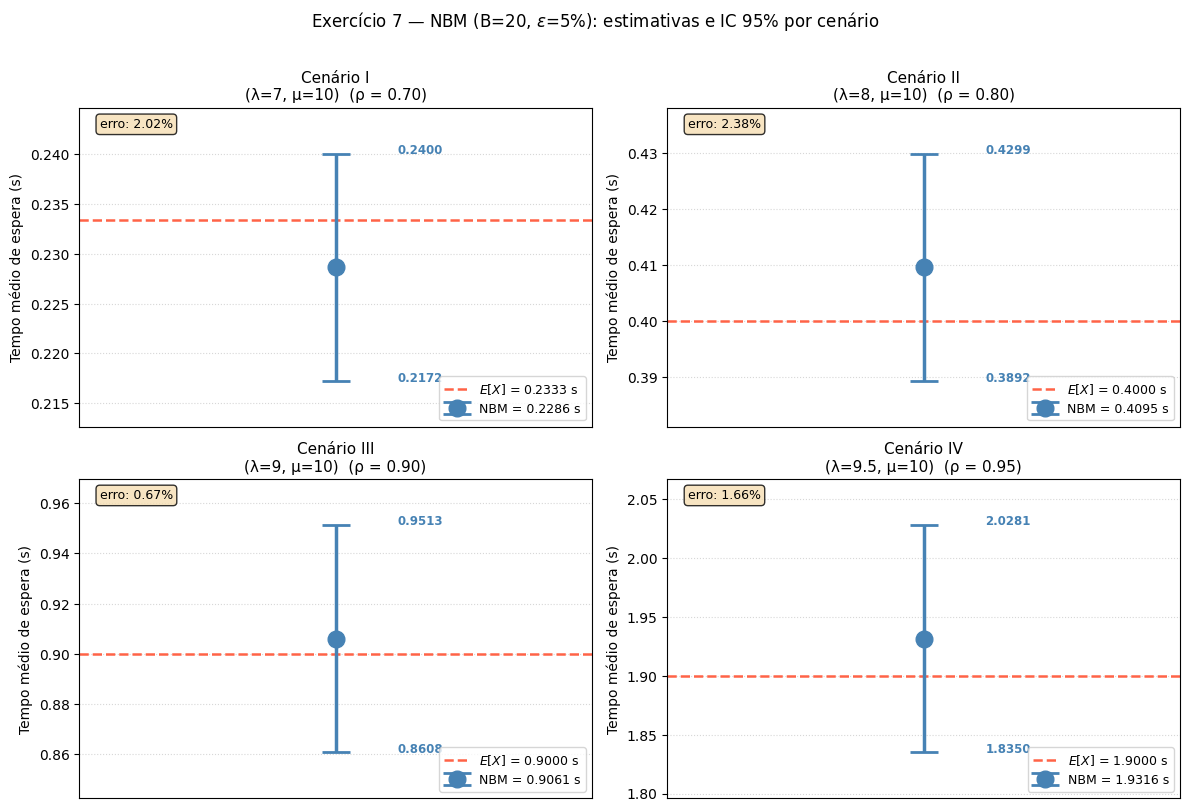

> **NBM** (B=20, ε=5%): menor erro relativo no Cenário III (0.67%). Tamanho amostral cresce com ρ: de N=77,500 (ρ=0,70) a N=1,250,000 (ρ=0,95).

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
slabels = [
    "Cenário I\n(λ=7, μ=10)",
    "Cenário II\n(λ=8, μ=10)",
    "Cenário III\n(λ=9, μ=10)",
    "Cenário IV\n(λ=9.5, μ=10)",
]

for result, ax, slabel in zip(results, axes, slabels):
    lam, mu = result["scenario"]
    rho = lam / mu
    E_X = result["E_X_theoretical"]
    mean_est, H = result["mean"], result["half_width"]

    ax.axhline(
        E_X,
        color="tomato",
        linestyle="--",
        linewidth=1.8,
        label=rf"$E[X]$ = {E_X:.4f} s",
        zorder=2,
    )
    ax.errorbar(
        1,
        mean_est,
        yerr=H,
        fmt="o",
        color="steelblue",
        markersize=12,
        linewidth=2.5,
        capsize=10,
        capthick=2,
        label=f"NBM = {mean_est:.4f} s",
        zorder=3,
    )
    ax.text(
        1.12,
        mean_est + H,
        f"{mean_est+H:.4f}",
        fontsize=8.5,
        color="steelblue",
        weight="bold",
    )
    ax.text(
        1.12,
        mean_est - H,
        f"{mean_est-H:.4f}",
        fontsize=8.5,
        color="steelblue",
        weight="bold",
    )

    erro_rel = abs(mean_est - E_X) / E_X
    ax.text(
        0.04,
        0.97,
        f"erro: {erro_rel:.2%}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
    )
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel("Tempo médio de espera (s)", fontsize=10)
    ax.set_title(f"{slabel}  (ρ = {rho:.2f})", fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ymargin = max(H, abs(mean_est - E_X)) * 0.4
    ax.set_ylim(min(mean_est - H, E_X) - ymargin, max(mean_est + H, E_X) + ymargin)

fig.suptitle(
    r"Exercício 7 — NBM (B=20, $\varepsilon$=5%): estimativas e IC 95% por cenário",
    fontsize=12,
    y=1.01,
)
fig.tight_layout()
fig.savefig("imgs/exercicio7.png", dpi=150, bbox_inches="tight")
plt.show()

best = int(
    np.argmin(
        [abs(r["mean"] - r["E_X_theoretical"]) / r["E_X_theoretical"] for r in results]
    )
)
display(
    Markdown(
        rf"> **NBM** (B=20, ε=5%): menor erro relativo no Cenário "
        rf"{'I II III IV'.split()[best]} "
        rf"({abs(results[best]['mean']-results[best]['E_X_theoretical'])/results[best]['E_X_theoretical']:.2%}). "
        rf"Tamanho amostral cresce com ρ: de N={results[0]['N']:,} (ρ=0,70) "
        rf"a N={results[3]['N']:,} (ρ=0,95)."
    )
)

---
## Exercício 8 — Método das Médias em Lote Espaçadas (SBM)

Variante do NBM que insere **S observações de espaçamento** entre lotes consecutivos para reduzir a correlação serial. Testado com dois valores:

- **S = 1** (fixo): espaçamento mínimo entre lotes
- **S = ⌊M/10⌋** (adaptativo): espaçamento cresce com o número de lotes M

$$H = z_{0{,}975}\,\frac{\hat{\sigma}_{\text{SBM}}}{\sqrt{M}}, \qquad \hat{\sigma}^2_{\text{SBM}} = \frac{1}{M-1}\sum_{j=1}^{M}(\bar{Y}_j - \bar{X})^2$$

Critério de parada: H/X̄ ≤ 5 %. Cenários I–IV.

In [13]:
def sbm_simulation(lam, mu, S_mode="fixed", B_init=20, M_init=100, epsilon=0.05, seed=None):
    RVN_CRITICO = 1.44
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim, buf, d, _ = _mser5y_warmup(lam, mu, seed)
    B = B_init
    M = M_init

    while True:
        S = 1 if S_mode == "fixed" else max(1, M // 10)
        N = B * M
        buf = _grow_buffer(sim, buf, N)
        amostra = buf[:N]

        # cada lote de M obs: usa as M-S primeiras, descarta as últimas S
        bm = amostra.reshape(B, M)[:, :-S].mean(axis=1)

        if _calcular_rvn(bm) <= RVN_CRITICO:
            M += 50
            continue

        mean_ = float(bm.mean())
        H = float(sp_stats.t.ppf(0.975, B - 1) * sp_stats.sem(bm))
        precisao = H / mean_ if mean_ > 0 else np.inf

        if precisao <= epsilon:
            return {
                "scenario": (lam, mu),
                "S_mode": S_mode,
                "d": d,
                "N": d + N,
                "M": B,
                "S": S,
                "mean": mean_,
                "half_width": H,
                "ci_lower": mean_ - H,
                "ci_upper": mean_ + H,
                "E_X_theoretical": E_X,
                "ci_contains_true": mean_ - H <= E_X <= mean_ + H,
                "batch_means": bm,
            }
        else:
            B += 5



── S = 1 (fixo) ─────────────────────────────────────────────────────────────────
  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.228640  │  0.011393  │    [0.217247 ; 0.240032]     │    78,000 │       0  ✓
       II │  0.80  │  0.409578  │  0.020385  │    [0.389193 ; 0.429962]     │   122,295 │     295  ✓
      III │  0.90  │  0.906053  │  0.045261  │    [0.860791 ; 0.951314]     │   474,000 │       0  ✓
       IV │  0.95  │  1.931586  │  0.096577  │    [1.835009 ; 2.028163]     │ 1,250,000 │       0  ✓

── S = ⌊M/10⌋ (adaptativo) ─────────────────────────────────────────────────────
  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.244902  │  0.01

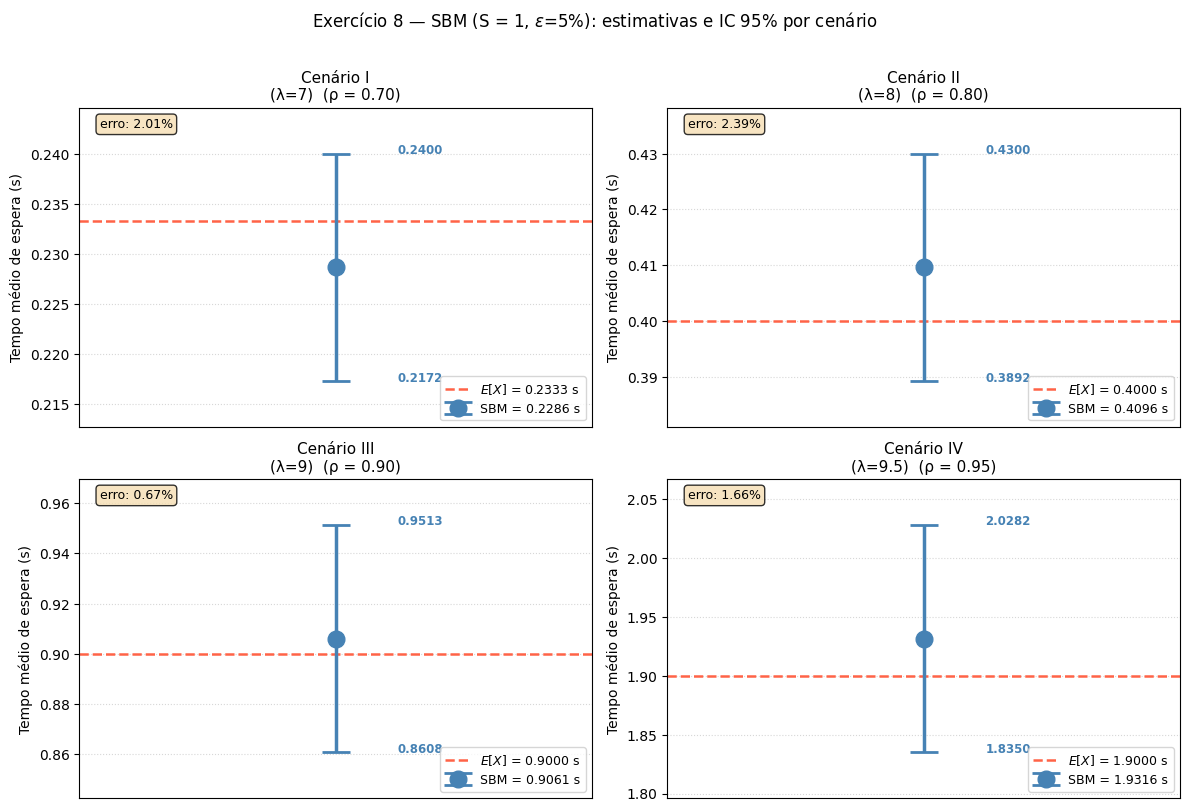

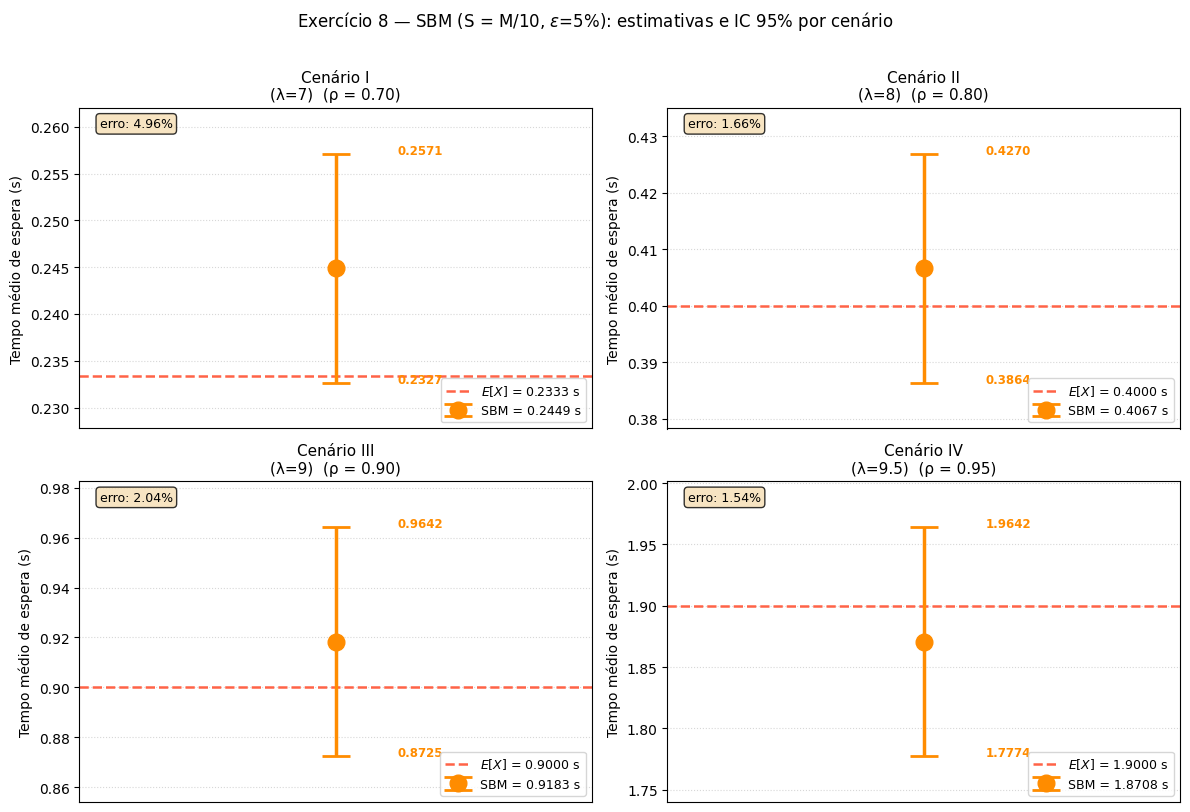

> **SBM**: espaçamento adaptativo (S=M/10) usa batches maiores mas exige mais observações. No Cenário IV: N=1,250,000 (S=1) vs N=884,565 (S=M/10).

In [14]:
# S ∈ {1, ⌊M/10⌋}, ε = 5%, cenários I–IV
scenarios = [(7.0, 10.0, "I"), (8.0, 10.0, "II"), (9.0, 10.0, "III"), (9.5, 10.0, "IV")]

results_sbm_fixed = []
results_sbm_adaptive = []
for lam, mu, label in scenarios:
    results_sbm_fixed.append(
        sbm_simulation(lam, mu, S_mode="fixed", seed=SEED + int(lam * 10))
    )
    results_sbm_adaptive.append(
        sbm_simulation(lam, mu, S_mode="adaptive", seed=SEED + int(lam * 10) + 100)
    )


def _sbm_table(rs, title):
    W = 10
    print(f"\n{title}")
    header = f"{'Cenário':>9} │ {'ρ':^6} │ {'X̄(n)':^{W}} │ {'H':^{W}} │ {'IC (95 %)':^28} │ {'N':>9} │ {'d':>7}"
    print(header)
    print("─" * len(header))
    for r, (lam, mu, label) in zip(rs, scenarios):
        rho = lam / mu
        ic = f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]"
        mark = "✓" if r["ci_contains_true"] else "✗"
        print(
            f"{'  '+label:>9} │ {rho:^6.2f} │ {r['mean']:^{W}.6f} │ {r['half_width']:^{W}.6f} │ {ic:^28} │ {r['N']:>9,} │ {r['d']:>7,}  {mark}"
        )


_sbm_table(
    results_sbm_fixed,
    "── S = 1 (fixo) ─────────────────────────────────────────────────────────────────",
)
_sbm_table(
    results_sbm_adaptive,
    "── S = ⌊M/10⌋ (adaptativo) ─────────────────────────────────────────────────────",
)

# ── Gráficos ──────────────────────────────────────────────────────────────────
slabels = [
    "Cenário I\n(λ=7)",
    "Cenário II\n(λ=8)",
    "Cenário III\n(λ=9)",
    "Cenário IV\n(λ=9.5)",
]
configs = [
    (results_sbm_fixed, "S = 1", "steelblue", "imgs/exercicio8_s1.png"),
    (results_sbm_adaptive, "S = M/10", "darkorange", "imgs/exercicio8_sM10.png"),
]

for mode_res, mode_label, color, fname in configs:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()

    for result, ax, slabel in zip(mode_res, axes, slabels):
        lam, mu = result["scenario"]
        rho = lam / mu
        E_X = result["E_X_theoretical"]
        mean_est, H = result["mean"], result["half_width"]

        ax.axhline(
            E_X,
            color="tomato",
            linestyle="--",
            linewidth=1.8,
            label=rf"$E[X]$ = {E_X:.4f} s",
            zorder=2,
        )
        ax.errorbar(
            1,
            mean_est,
            yerr=H,
            fmt="o",
            color=color,
            markersize=12,
            linewidth=2.5,
            capsize=10,
            capthick=2,
            label=f"SBM = {mean_est:.4f} s",
            zorder=3,
        )
        ax.text(
            1.12,
            mean_est + H,
            f"{mean_est+H:.4f}",
            fontsize=8.5,
            color=color,
            weight="bold",
        )
        ax.text(
            1.12,
            mean_est - H,
            f"{mean_est-H:.4f}",
            fontsize=8.5,
            color=color,
            weight="bold",
        )

        erro_rel = abs(mean_est - E_X) / E_X
        ax.text(
            0.04,
            0.97,
            f"erro: {erro_rel:.2%}",
            transform=ax.transAxes,
            fontsize=9,
            va="top",
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
        )
        ax.set_xlim(0.5, 1.5)
        ax.set_xticks([])
        ax.set_ylabel("Tempo médio de espera (s)", fontsize=10)
        ax.set_title(f"{slabel}  (ρ = {rho:.2f})", fontsize=11)
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, axis="y", linestyle=":", alpha=0.5)
        ymargin = max(H, abs(mean_est - E_X)) * 0.4
        ax.set_ylim(min(mean_est - H, E_X) - ymargin, max(mean_est + H, E_X) + ymargin)

    fig.suptitle(
        rf"Exercício 8 — SBM ({mode_label}, $\varepsilon$=5%): estimativas e IC 95% por cenário",
        fontsize=12,
        y=1.01,
    )
    fig.tight_layout()
    fig.savefig(fname, dpi=150, bbox_inches="tight")
    plt.show()

display(
    Markdown(
        rf"> **SBM**: espaçamento adaptativo (S=M/10) usa batches maiores mas exige mais observações. "
        rf"No Cenário IV: N={results_sbm_fixed[3]['N']:,} (S=1) vs "
        rf"N={results_sbm_adaptive[3]['N']:,} (S=M/10)."
    )
)

---
## Exercício 9 — Método das Médias em Lote Sobrepostas (OBM)

Generalização do NBM em que lotes de tamanho **m = 100** se sobrepõem com passo **lag**. O grau de sobreposição determina a correlação entre lotes consecutivos:

| Sobreposição | lag |
|:---:|:---:|
| 100 % | 1 |
| 50 % | m/2 |
| 25 % | 3m/4 |

Critério de parada: H/X̄ ≤ 5 %. Comparação dos três graus nos quatro cenários.

In [15]:
def obm_simulation(lam, mu, overlap_pct=100, B_init=20, M_init=100, epsilon=0.05, seed=None):
    RVN_CRITICO = 1.44
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim, buf, d, _ = _mser5y_warmup(lam, mu, seed)
    B = B_init
    M = M_init  # tamanho da janela; cresce quando RVN falha ou precisão insuficiente

    while True:
        N = B * M
        buf = _grow_buffer(sim, buf, N)
        amostra = buf[:N]

        # RVN em lotes não sobrepostos para calibrar M
        medias_nbm = amostra.reshape(B, M).mean(axis=1)
        if _calcular_rvn(medias_nbm) <= RVN_CRITICO:
            M += 50
            continue

        overlap = overlap_pct / 100.0
        passo = max(1, int(M * (1.0 - overlap))) if overlap < 1.0 else 1
        medias_obm = np.array(
            [amostra[i : i + M].mean() for i in range(0, N - M + 1, passo)],
            dtype=np.float64,
        )
        B_linha = len(medias_obm)

        mean_ = float(medias_obm.mean())
        var = float(np.var(medias_obm, ddof=1))
        gl = max(1, int(1.5 * (B_linha - 1)))
        H = float(sp_stats.t.ppf(0.975, gl) * np.sqrt(var / B_linha))
        precisao = H / mean_ if mean_ > 0 else np.inf

        if precisao <= epsilon:
            return {
                "scenario": (lam, mu),
                "overlap_pct": overlap_pct,
                "d": d,
                "N": d + N,
                "M": B_linha,
                "S": M,
                "lag": passo,
                "mean": mean_,
                "half_width": H,
                "ci_lower": mean_ - H,
                "ci_upper": mean_ + H,
                "E_X_theoretical": E_X,
                "ci_contains_true": mean_ - H <= E_X <= mean_ + H,
                "batch_means": medias_obm,
            }
        else:
            M += 50



── Sobreposição 100%  (lag = 1) ─────────────────────────────────────────────────────────────
  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.208255  │  0.004689  │    [0.203566 ; 0.212944]     │     3,395 │   1,395  ✗
       II │  0.80  │  0.433065  │  0.012468  │    [0.420598 ; 0.445533]     │     3,000 │       0  ✗
      III │  0.90  │  1.021436  │  0.018807  │    [1.002628 ; 1.040243]     │     5,000 │       0  ✗
       IV │  0.95  │  1.870855  │  0.024899  │    [1.845956 ; 1.895755]     │    19,065 │   9,065  ✗

── Sobreposição 50%  (lag = 1250) ─────────────────────────────────────────────────────────────
  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │ 

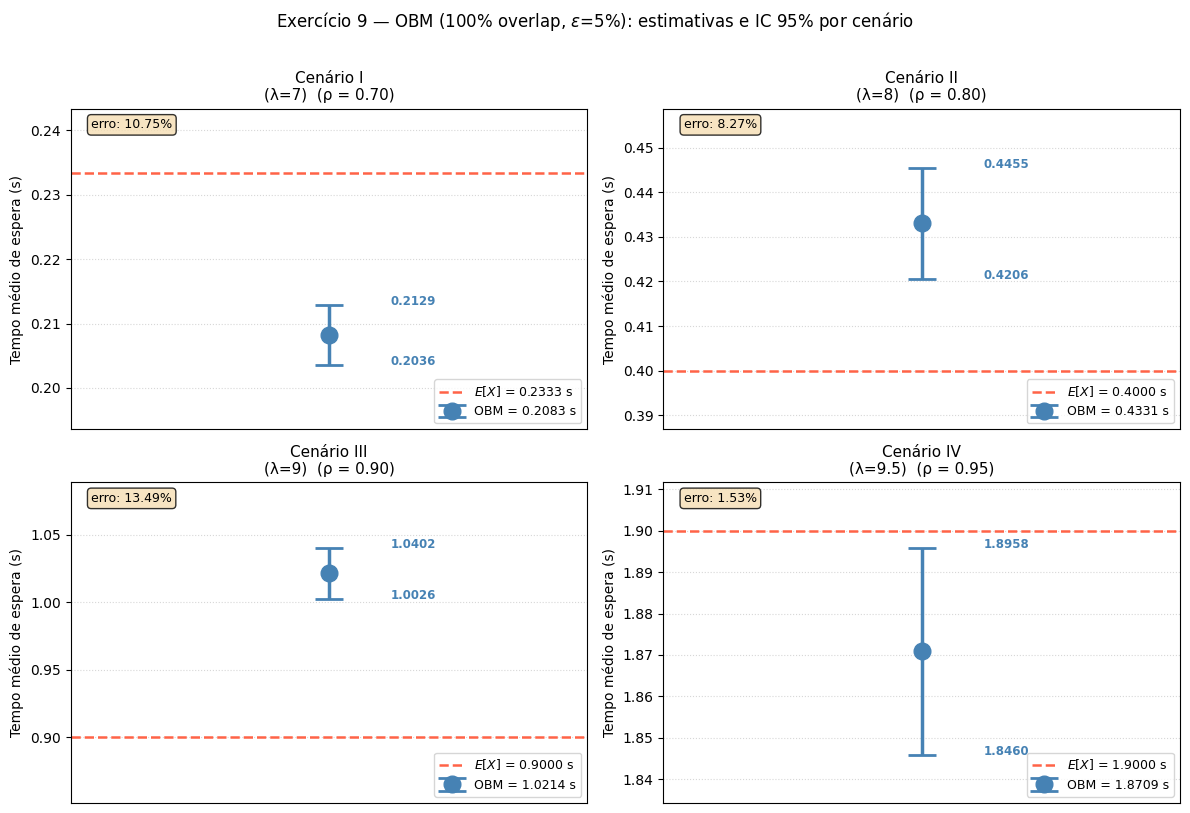

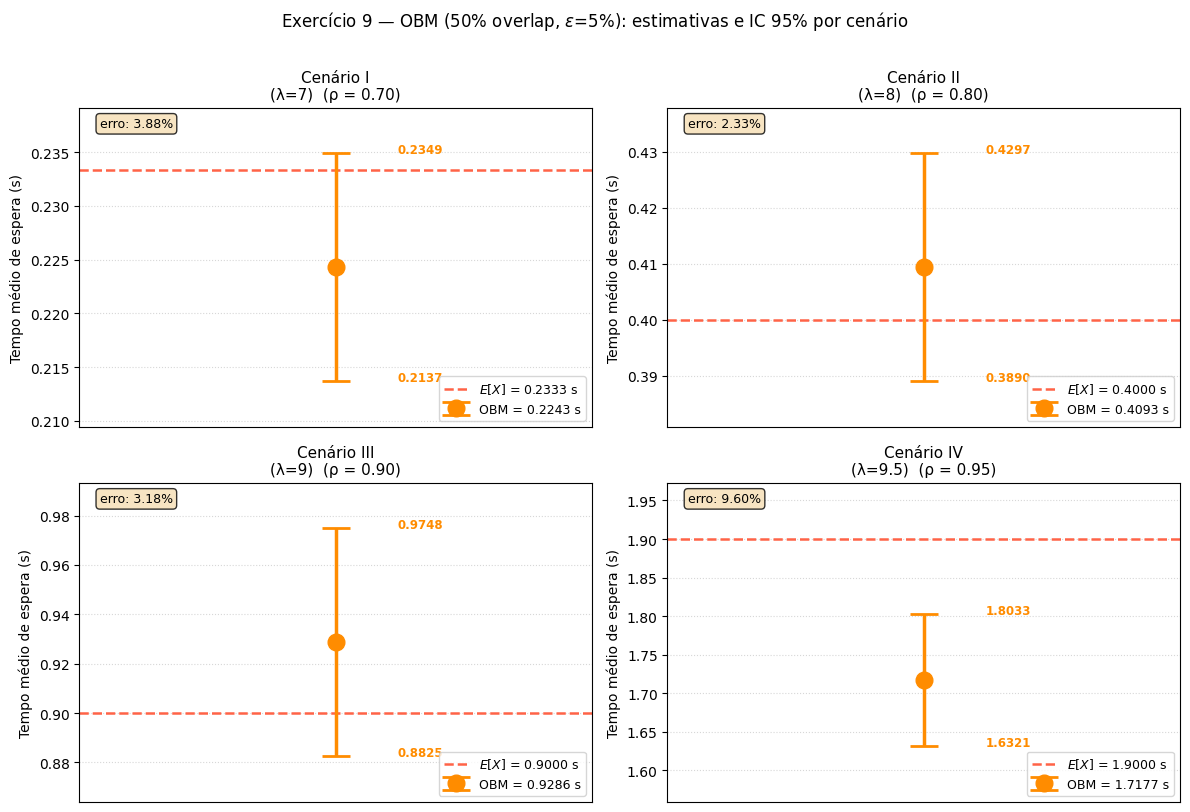

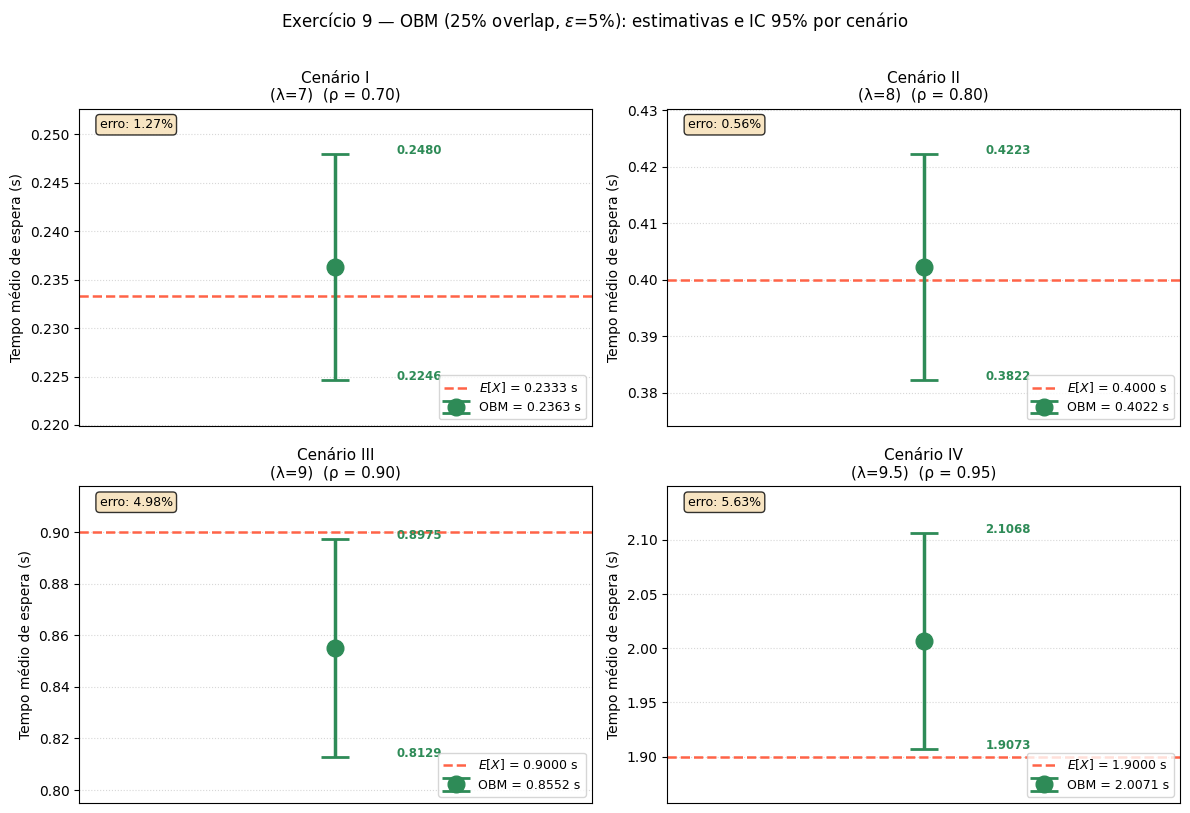

> **OBM**: maior sobreposição (100%) maximiza reúso de dados mas eleva a correlação entre lotes, inflando o estimador de variância. Sobreposição reduzida (25%) se aproxima do NBM não sobreposto.

In [16]:
# overlap ∈ {100%, 50%, 25%}, ε = 5%, cenários I–IV
scenarios = [(7.0, 10.0, "I"), (8.0, 10.0, "II"), (9.0, 10.0, "III"), (9.5, 10.0, "IV")]
overlap_percentages = [100, 50, 25]

results_obm = {pct: [] for pct in overlap_percentages}
for pct in overlap_percentages:
    for lam, mu, label in scenarios:
        results_obm[pct].append(
            obm_simulation(lam, mu, overlap_pct=pct, seed=SEED + int(lam * 10) + pct)
        )


def _obm_table(rs, title):
    W = 10
    print(f"\n{title}")
    header = f"{'Cenário':>9} │ {'ρ':^6} │ {'X̄(n)':^{W}} │ {'H':^{W}} │ {'IC (95 %)':^28} │ {'N':>9} │ {'d':>7}"
    print(header)
    print("─" * len(header))
    for r, (lam, mu, label) in zip(rs, scenarios):
        rho = lam / mu
        ic = f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]"
        mark = "✓" if r["ci_contains_true"] else "✗"
        print(
            f"{'  '+label:>9} │ {rho:^6.2f} │ {r['mean']:^{W}.6f} │ {r['half_width']:^{W}.6f} │ {ic:^28} │ {r['N']:>9,} │ {r['d']:>7,}  {mark}"
        )


for pct in overlap_percentages:
    lag = results_obm[pct][0]["lag"]
    _obm_table(
        results_obm[pct],
        f"── Sobreposição {pct}%  (lag = {lag}) ─────────────────────────────────────────────────────────────",
    )

# ── Gráficos ──────────────────────────────────────────────────────────────────
slabels = [
    "Cenário I\n(λ=7)",
    "Cenário II\n(λ=8)",
    "Cenário III\n(λ=9)",
    "Cenário IV\n(λ=9.5)",
]
colors = {100: "steelblue", 50: "darkorange", 25: "seagreen"}
fnames = {
    100: "imgs/exercicio9_100.png",
    50: "imgs/exercicio9_50.png",
    25: "imgs/exercicio9_25.png",
}

for pct in overlap_percentages:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    color = colors[pct]

    for result, ax, slabel in zip(results_obm[pct], axes, slabels):
        lam, mu = result["scenario"]
        rho = lam / mu
        E_X = result["E_X_theoretical"]
        mean_est, H = result["mean"], result["half_width"]

        ax.axhline(
            E_X,
            color="tomato",
            linestyle="--",
            linewidth=1.8,
            label=rf"$E[X]$ = {E_X:.4f} s",
            zorder=2,
        )
        ax.errorbar(
            1,
            mean_est,
            yerr=H,
            fmt="o",
            color=color,
            markersize=12,
            linewidth=2.5,
            capsize=10,
            capthick=2,
            label=f"OBM = {mean_est:.4f} s",
            zorder=3,
        )
        ax.text(
            1.12,
            mean_est + H,
            f"{mean_est+H:.4f}",
            fontsize=8.5,
            color=color,
            weight="bold",
        )
        ax.text(
            1.12,
            mean_est - H,
            f"{mean_est-H:.4f}",
            fontsize=8.5,
            color=color,
            weight="bold",
        )

        erro_rel = abs(mean_est - E_X) / E_X
        ax.text(
            0.04,
            0.97,
            f"erro: {erro_rel:.2%}",
            transform=ax.transAxes,
            fontsize=9,
            va="top",
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
        )
        ax.set_xlim(0.5, 1.5)
        ax.set_xticks([])
        ax.set_ylabel("Tempo médio de espera (s)", fontsize=10)
        ax.set_title(f"{slabel}  (ρ = {rho:.2f})", fontsize=11)
        ax.legend(fontsize=9, loc="lower right")
        ax.grid(True, axis="y", linestyle=":", alpha=0.5)
        ymargin = max(H, abs(mean_est - E_X)) * 0.4
        ax.set_ylim(min(mean_est - H, E_X) - ymargin, max(mean_est + H, E_X) + ymargin)

    fig.suptitle(
        rf"Exercício 9 — OBM ({pct}% overlap, $\varepsilon$=5%): estimativas e IC 95% por cenário",
        fontsize=12,
        y=1.01,
    )
    fig.tight_layout()
    fig.savefig(fnames[pct], dpi=150, bbox_inches="tight")
    plt.show()

display(
    Markdown(
        r"> **OBM**: maior sobreposição (100%) maximiza reúso de dados mas eleva a correlação entre lotes, "
        r"inflando o estimador de variância. Sobreposição reduzida (25%) se aproxima do NBM "
        r"não sobreposto."
    )
)

---
## Exercício 10 — Séries Temporais Padronizadas: variante ÁREA (STS/ÁREA)

Estima σ² via **área geométrica** de cada lote. Para o lote *i* de *M* observações:

$$A_i = \sum_{j=1}^{M}\left(\frac{M+1}{2} - j\right)X_{(i-1)M+j}, \qquad H = t_{B,\,\alpha/2}\sqrt{\frac{12\sum_{i=1}^{B} A_i^2}{N^2(M^2-1)}}$$

Normalidade das áreas verificada por Shapiro-Wilk (α = 5%). B = 20 lotes fixos; M cresce de 50 em 50 até as áreas serem normais e H/X̄ ≤ 5%. Cenários I–IV.

In [17]:
def sts_area_simulation(lam, mu, B_init=20, M_init=100, epsilon=0.05, seed=None):
    ALPHA = 0.05
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim, buf, d, _ = _mser5y_warmup(lam, mu, seed)
    B = B_init
    M = M_init
    normalidade_confirmada = False

    while True:
        N = B * M
        buf = _grow_buffer(sim, buf, N)
        amostra = buf[:N]

        blocos = amostra.reshape(B, M)
        pesos = (M + 1) / 2.0 - np.arange(1, M + 1)
        areas = blocos @ pesos  # shape (B,)

        if not normalidade_confirmada:
            _, p_valor = sp_stats.shapiro(areas)
            if p_valor < ALPHA:
                M += 50
                continue
            normalidade_confirmada = True

        mean_ = float(amostra.mean())
        soma = float(np.sum(areas ** 2))
        H = float(sp_stats.t.ppf(1 - ALPHA / 2, B) * np.sqrt(12 * soma / (N ** 2 * (M ** 2 - 1))))
        precisao = H / mean_ if mean_ > 0 else np.inf

        if precisao <= epsilon:
            return {
                "scenario": (lam, mu),
                "d": d,
                "N": d + N,
                "B": B,
                "M": B,
                "batch_size": M,
                "mean": mean_,
                "half_width": H,
                "ci_lower": mean_ - H,
                "ci_upper": mean_ + H,
                "E_X_theoretical": E_X,
                "ci_contains_true": mean_ - H <= E_X <= mean_ + H,
                "batch_means": blocos.mean(axis=1),
            }
        else:
            M += 50


  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.233456  │  0.010558  │    [0.222898 ; 0.244014]     │    52,000 │       0  ✓
       II │  0.80  │  0.394247  │  0.019300  │    [0.374946 ; 0.413547]     │   101,000 │       0  ✓
      III │  0.90  │  0.898983  │  0.044568  │    [0.854416 ; 0.943551]     │   426,910 │   4,910  ✓
       IV │  0.95  │  1.945316  │  0.097043  │    [1.848274 ; 2.042359]     │ 1,492,000 │       0  ✓


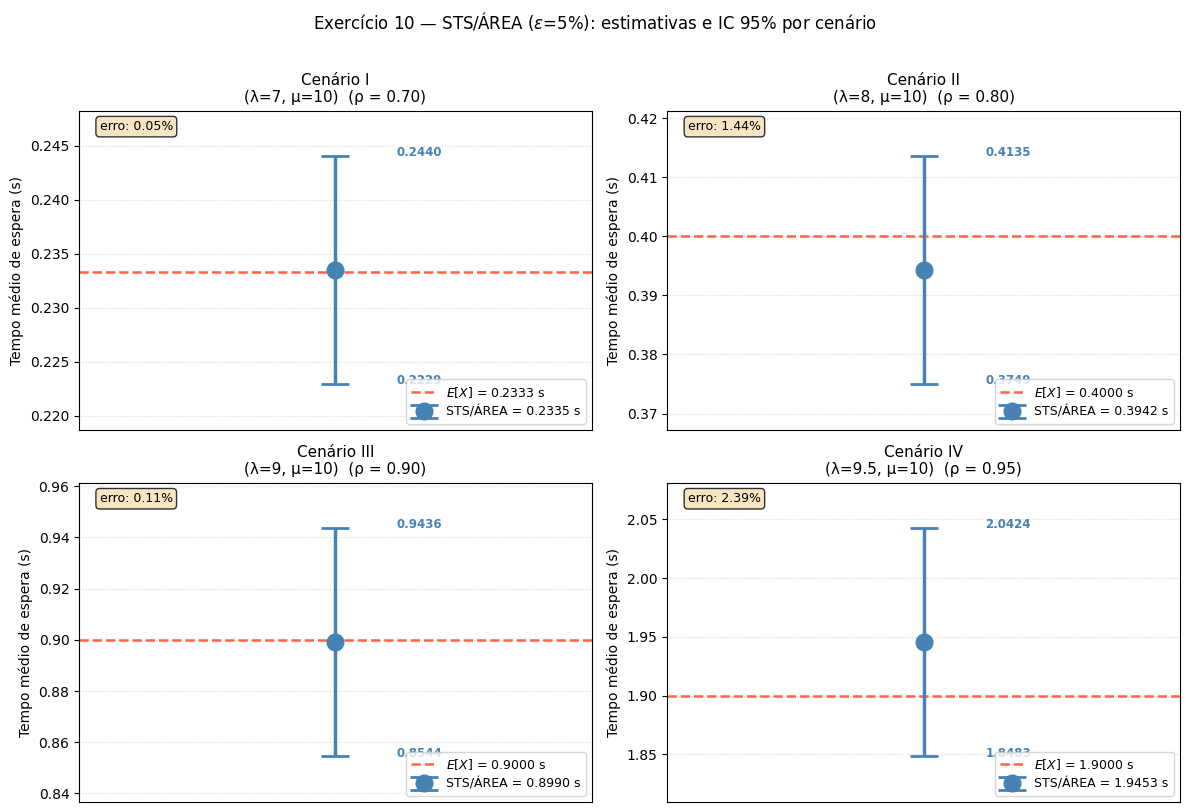

> **STS/ÁREA**: IC via área geométrica dos lotes (Shapiro-Wilk para normalidade). Cenário IV: N=1,492,000 obs, tamanho de lote M=74600.

In [18]:
# B = 20 lotes fixos, M cresce de 50 em 50, ε = 5%, cenários I–IV
scenarios = [(7.0, 10.0, "I"), (8.0, 10.0, "II"), (9.0, 10.0, "III"), (9.5, 10.0, "IV")]

results_sts = []
for lam, mu, label in scenarios:
    results_sts.append(sts_area_simulation(lam, mu, seed=SEED + int(lam * 10) + 200))

W = 10
header = f"{'Cenário':>9} │ {'ρ':^6} │ {'X̄(n)':^{W}} │ {'H':^{W}} │ {'IC (95 %)':^28} │ {'N':>9} │ {'d':>7}"
sep = "─" * len(header)
print(header)
print(sep)
for r, (lam, mu, label) in zip(results_sts, scenarios):
    rho = lam / mu
    ic = f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]"
    mark = "✓" if r["ci_contains_true"] else "✗"
    print(
        f"{'  '+label:>9} │ {rho:^6.2f} │ {r['mean']:^{W}.6f} │ {r['half_width']:^{W}.6f} │ {ic:^28} │ {r['N']:>9,} │ {r['d']:>7,}  {mark}"
    )

# ── Gráfico ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
slabels = [
    "Cenário I\n(λ=7, μ=10)",
    "Cenário II\n(λ=8, μ=10)",
    "Cenário III\n(λ=9, μ=10)",
    "Cenário IV\n(λ=9.5, μ=10)",
]

for result, ax, slabel in zip(results_sts, axes, slabels):
    lam, mu = result["scenario"]
    rho = lam / mu
    E_X = result["E_X_theoretical"]
    mean_est, H = result["mean"], result["half_width"]

    ax.axhline(E_X, color="tomato", linestyle="--", linewidth=1.8,
               label=rf"$E[X]$ = {E_X:.4f} s", zorder=2)
    ax.errorbar(1, mean_est, yerr=H, fmt="o", color="steelblue",
                markersize=12, linewidth=2.5, capsize=10, capthick=2,
                label=f"STS/ÁREA = {mean_est:.4f} s", zorder=3)
    ax.text(1.12, mean_est + H, f"{mean_est+H:.4f}", fontsize=8.5,
            color="steelblue", weight="bold")
    ax.text(1.12, mean_est - H, f"{mean_est-H:.4f}", fontsize=8.5,
            color="steelblue", weight="bold")

    erro_rel = abs(mean_est - E_X) / E_X
    ax.text(0.04, 0.97, f"erro: {erro_rel:.2%}",
            transform=ax.transAxes, fontsize=9, va="top",
            bbox=dict(boxstyle="round", fc="wheat", alpha=0.8))
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel("Tempo médio de espera (s)", fontsize=10)
    ax.set_title(f"{slabel}  (ρ = {rho:.2f})", fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ymargin = max(H, abs(mean_est - E_X)) * 0.4
    ax.set_ylim(min(mean_est - H, E_X) - ymargin, max(mean_est + H, E_X) + ymargin)

fig.suptitle(
    r"Exercício 10 — STS/ÁREA ($\varepsilon$=5%): estimativas e IC 95% por cenário",
    fontsize=12, y=1.01,
)
fig.tight_layout()
fig.savefig("imgs/exercicio10.png", dpi=150, bbox_inches="tight")
plt.show()

display(Markdown(
    rf"> **STS/ÁREA**: IC via área geométrica dos lotes (Shapiro-Wilk para normalidade). "
    rf"Cenário IV: N={results_sts[3]['N']:,} obs, tamanho de lote M={results_sts[3]['batch_size']}."
))


---
## Exercício 11 — Séries Temporais Padronizadas: variante CSUM (STS/CSUM)

Combina a **área geométrica** de cada lote com a **variância inter-lote** para estimar σ²:

$$A = \sum_{i=1}^{B}\left[\frac{12\,A_i^2}{M^3 - M} + M\,(\bar{X} - \bar{X}_i)^2\right], \qquad H = t_{2B-1,\,\alpha/2}\sqrt{\frac{A}{N\,(2B-1)}}$$

Normalidade das áreas verificada por Shapiro-Wilk (α = 5%). B = 20 lotes fixos; M cresce de 50 em 50 até as áreas serem normais e H/X̄ ≤ 5%. Cenários I–IV.

In [19]:
def sts_csum_simulation(lam, mu, B_init=20, M_init=100, epsilon=0.05, seed=None):
    ALPHA = 0.05
    rho = lam / mu
    E_X = rho / (mu * (1.0 - rho))
    sim, buf, d, _ = _mser5y_warmup(lam, mu, seed)
    B = B_init
    M = M_init
    normalidade_confirmada = False

    while True:
        N = B * M
        buf = _grow_buffer(sim, buf, N)
        amostra = buf[:N]

        blocos = amostra.reshape(B, M)
        pesos = (M + 1) / 2.0 - np.arange(1, M + 1)
        areas = blocos @ pesos  # shape (B,)

        if not normalidade_confirmada:
            _, p_valor = sp_stats.shapiro(areas)
            if p_valor < ALPHA:
                M += 50
                continue
            normalidade_confirmada = True

        medias_bloco = blocos.mean(axis=1)
        mean_ = float(amostra.mean())

        A = float(np.sum(12 * areas ** 2 / (M ** 3 - M) + M * (mean_ - medias_bloco) ** 2))
        H = float(sp_stats.t.ppf(1 - ALPHA / 2, 2 * B - 1) * np.sqrt(A / (N * (2 * B - 1))))
        precisao = H / mean_ if mean_ > 0 else np.inf

        if precisao <= epsilon:
            return {
                "scenario": (lam, mu),
                "d": d,
                "N": d + N,
                "B": B,
                "M": M,
                "N_steady": N,
                "var_csum": A / (N * (2 * B - 1)),
                "mean": mean_,
                "half_width": H,
                "ci_lower": mean_ - H,
                "ci_upper": mean_ + H,
                "E_X_theoretical": E_X,
                "ci_contains_true": mean_ - H <= E_X <= mean_ + H,
            }
        else:
            M += 50


  Cenário │   ρ    │   X̄(n)    │     H      │          IC (95 %)           │  σ²_CSUM  │         N │       d
─────────────────────────────────────────────────────────────────────────────────────────────────────────────
        I │  0.70  │  0.224999  │  0.011218  │    [0.213782 ; 0.236217]     │  0.0000   │    78,000 │       0  ✓
       II │  0.80  │  0.375560  │  0.018776  │    [0.356784 ; 0.394336]     │  0.0001   │   103,000 │       0  ✗
      III │  0.90  │  0.874148  │  0.043469  │    [0.830678 ; 0.917617]     │  0.0005   │   539,000 │       0  ✓
       IV │  0.95  │  1.965395  │  0.098127  │    [1.867268 ; 2.063522]     │  0.0024   │ 3,515,000 │       0  ✓


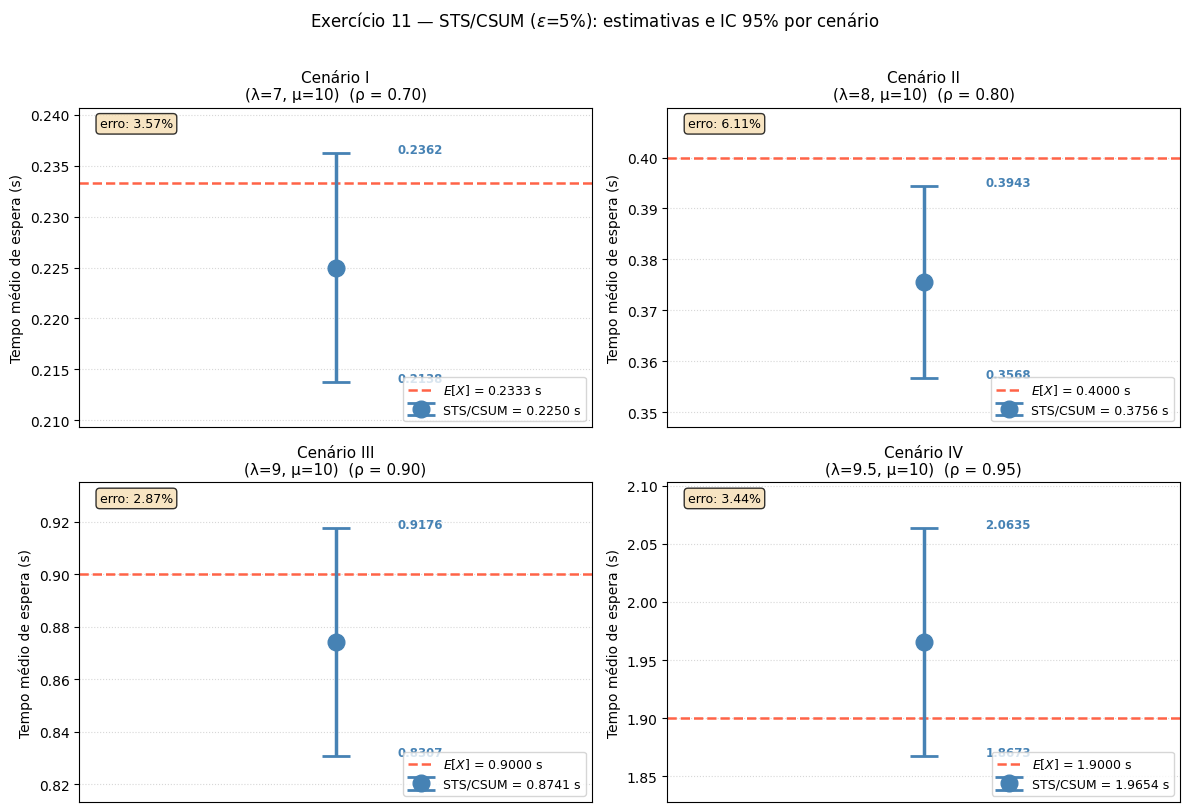

> **STS/CSUM**: σ²_CSUM cresce com ρ — de 0.00 (ρ=0,70) a 0.00 (ρ=0,95) —, refletindo autocorrelação crescente. No Cenário IV o método exige N=3,515,000 obs para atingir ε=5%.

In [20]:
# n cresce de 500 em 500, ε = 5%, cenários I–IV
scenarios = [(7.0, 10.0, "I"), (8.0, 10.0, "II"), (9.0, 10.0, "III"), (9.5, 10.0, "IV")]

results_csum = []
for lam, mu, label in scenarios:
    results_csum.append(sts_csum_simulation(lam, mu, seed=SEED + int(lam * 10) + 300))

W = 10
header = f"{'Cenário':>9} │ {'ρ':^6} │ {'X̄(n)':^{W}} │ {'H':^{W}} │ {'IC (95 %)':^28} │ {'σ²_CSUM':^9} │ {'N':>9} │ {'d':>7}"
sep = "─" * len(header)
print(header)
print(sep)
for r, (lam, mu, label) in zip(results_csum, scenarios):
    rho = lam / mu
    ic = f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]"
    mark = "✓" if r["ci_contains_true"] else "✗"
    print(
        f"{'  '+label:>9} │ {rho:^6.2f} │ {r['mean']:^{W}.6f} │ {r['half_width']:^{W}.6f} │ {ic:^28} │ {r['var_csum']:^9.4f} │ {r['N']:>9,} │ {r['d']:>7,}  {mark}"
    )

# ── Gráfico ────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
slabels = [
    "Cenário I\n(λ=7, μ=10)",
    "Cenário II\n(λ=8, μ=10)",
    "Cenário III\n(λ=9, μ=10)",
    "Cenário IV\n(λ=9.5, μ=10)",
]

for result, ax, slabel in zip(results_csum, axes, slabels):
    lam, mu = result["scenario"]
    rho = lam / mu
    E_X = result["E_X_theoretical"]
    mean_est, H = result["mean"], result["half_width"]

    ax.axhline(
        E_X,
        color="tomato",
        linestyle="--",
        linewidth=1.8,
        label=rf"$E[X]$ = {E_X:.4f} s",
        zorder=2,
    )
    ax.errorbar(
        1,
        mean_est,
        yerr=H,
        fmt="o",
        color="steelblue",
        markersize=12,
        linewidth=2.5,
        capsize=10,
        capthick=2,
        label=f"STS/CSUM = {mean_est:.4f} s",
        zorder=3,
    )
    ax.text(
        1.12,
        mean_est + H,
        f"{mean_est+H:.4f}",
        fontsize=8.5,
        color="steelblue",
        weight="bold",
    )
    ax.text(
        1.12,
        mean_est - H,
        f"{mean_est-H:.4f}",
        fontsize=8.5,
        color="steelblue",
        weight="bold",
    )

    erro_rel = abs(mean_est - E_X) / E_X
    ax.text(
        0.04,
        0.97,
        f"erro: {erro_rel:.2%}",
        transform=ax.transAxes,
        fontsize=9,
        va="top",
        bbox=dict(boxstyle="round", fc="wheat", alpha=0.8),
    )
    ax.set_xlim(0.5, 1.5)
    ax.set_xticks([])
    ax.set_ylabel("Tempo médio de espera (s)", fontsize=10)
    ax.set_title(f"{slabel}  (ρ = {rho:.2f})", fontsize=11)
    ax.legend(fontsize=9, loc="lower right")
    ax.grid(True, axis="y", linestyle=":", alpha=0.5)
    ymargin = max(H, abs(mean_est - E_X)) * 0.4
    ax.set_ylim(min(mean_est - H, E_X) - ymargin, max(mean_est + H, E_X) + ymargin)

fig.suptitle(
    r"Exercício 11 — STS/CSUM ($\varepsilon$=5%): estimativas e IC 95% por cenário",
    fontsize=12,
    y=1.01,
)
fig.tight_layout()
fig.savefig("imgs/exercicio11.png", dpi=150, bbox_inches="tight")
plt.show()

display(
    Markdown(
        rf"> **STS/CSUM**: σ²_CSUM cresce com ρ — de "
        rf"{results_csum[0]['var_csum']:.2f} (ρ=0,70) a "
        rf"{results_csum[3]['var_csum']:.2f} (ρ=0,95) —, refletindo autocorrelação crescente. "
        rf"No Cenário IV o método exige N={results_csum[3]['N']:,} obs para atingir ε=5%."
    )
)

---
## Exercício 12 — Análise Comparativa dos Cinco Métodos

Compara os seis estimadores no **Cenário IV** (λ=9,5; μ=10; ρ=0,95) — o de maior autocorrelação — usando erro relativo a E[X], largura do IC e tamanho amostral N.

| # | Método | Parâmetro principal |
|--:|:---|:---|
| 7 | NBM | B = 20 lotes |
| 8a | SBM (S = 1) | espaçamento fixo |
| 8b | SBM (S = M/10) | espaçamento adaptativo |
| 9 | OBM (100 % overlap) | lag = 1 |
| 10 | STS/ÁREA | fator γ₀ (autocorrelação) |
| 11 | STS/CSUM | soma cumulativa |

E[X] teórico = 1.900000 s  (λ=9.5, μ=10.0, ρ=0.95)

      Método       X̄        H                IC 95%         N     d  Erro % E[X]∈IC
         NBM 1.931552 0.096557 [1.834995 ; 2.028110] 1,250,000     0 +1.661%       ✓
   SBM (S=1) 1.931586 0.096577 [1.835009 ; 2.028163] 1,250,000     0 +1.662%       ✓
SBM (S=M/10) 1.870786 0.093394 [1.777392 ; 1.964180]   884,565 9,065 -1.538%       ✓
  OBM (100%) 1.870855 0.024899 [1.845956 ; 1.895755]    19,065 9,065 -1.534%       ✗
    STS/ÁREA 1.945316 0.097043 [1.848274 ; 2.042359] 1,492,000     0 +2.385%       ✓
    STS/CSUM 1.965395 0.098127 [1.867268 ; 2.063522] 3,515,000     0 +3.442%       ✓


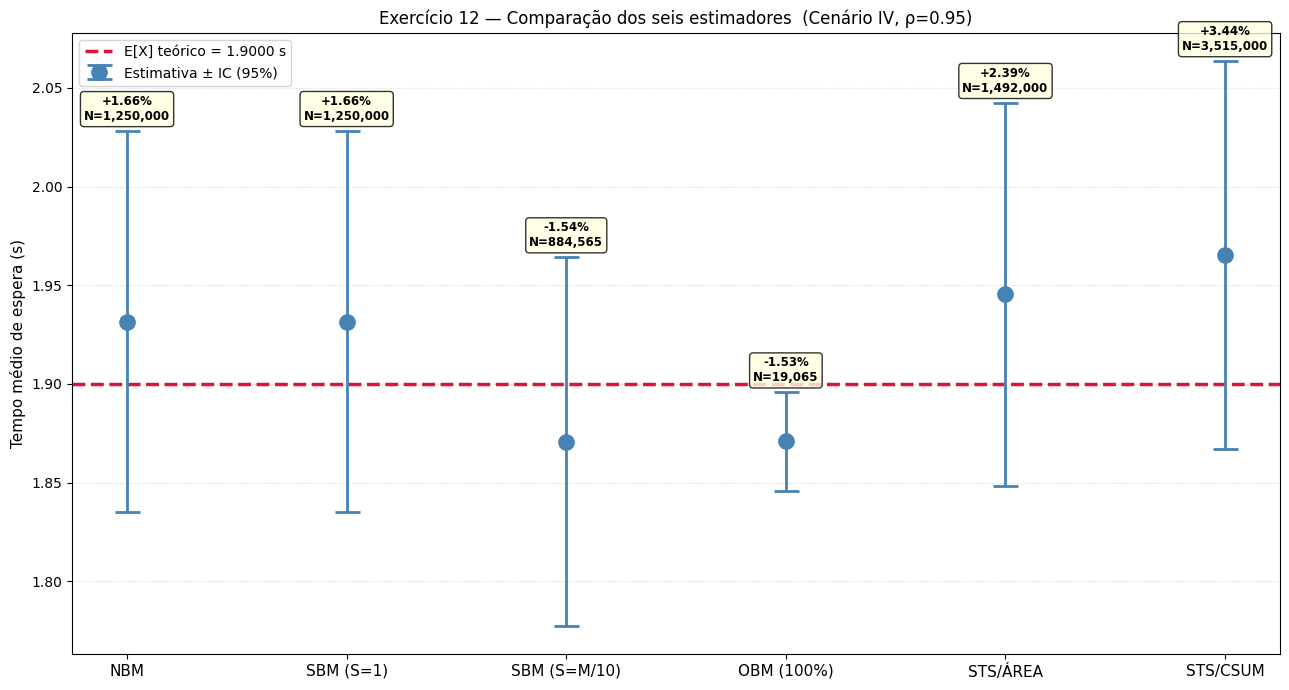

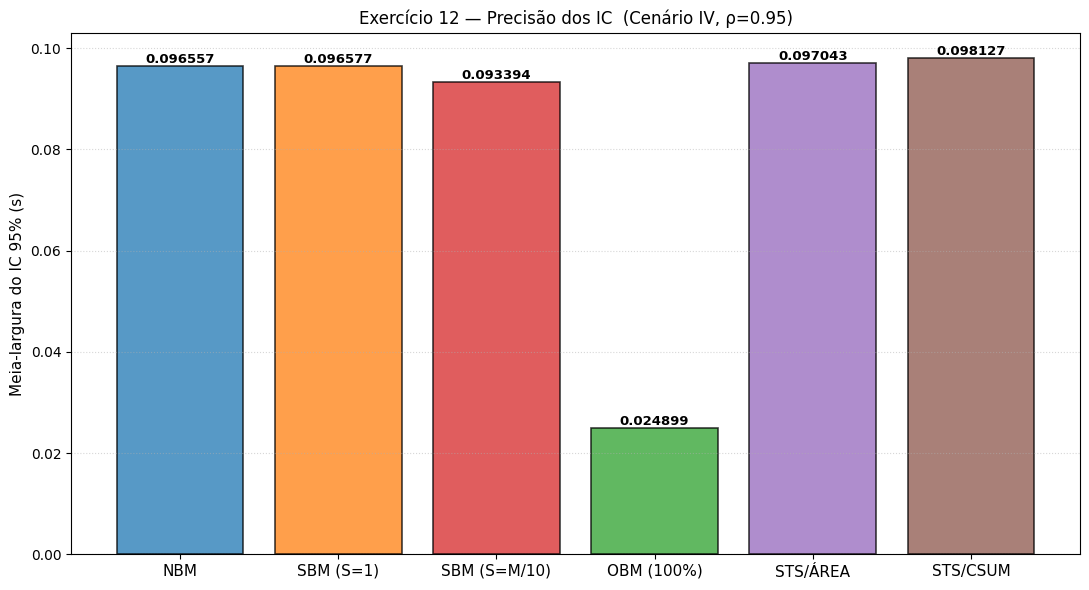

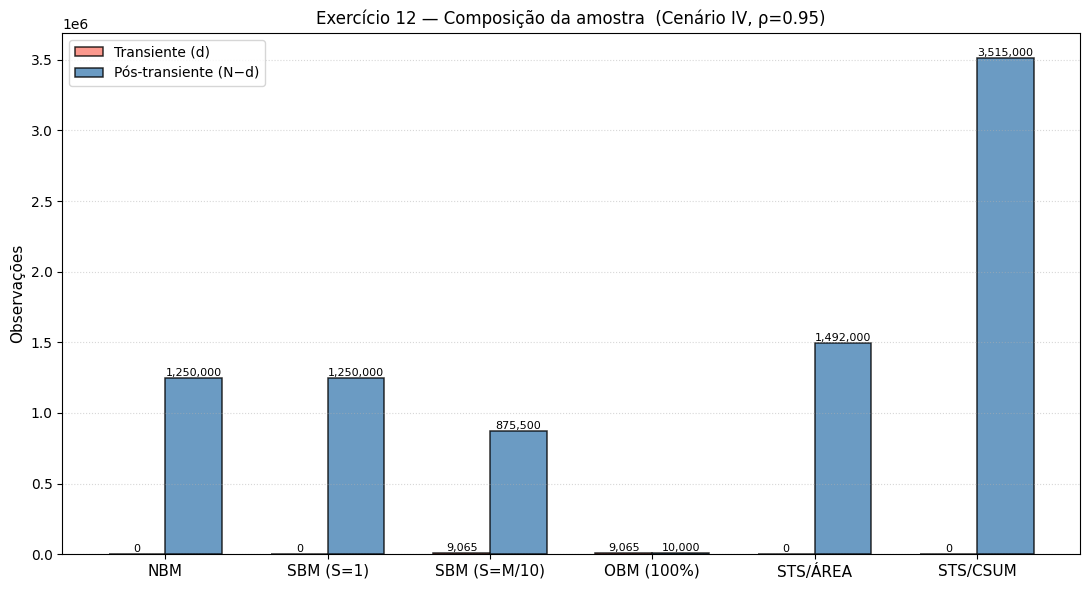

> **Cenário IV** (ρ=0,95): menor erro relativo → **OBM (100%)**; IC mais estreito → **OBM (100%)**. 5/6 ICs cobrem E[X] teórico. Todos os métodos usaram MSER-5Y e atingiram H/X̄ ≤ 5%.

In [21]:
# Cenário IV (λ=9.5, μ=10, ρ=0.95) — índice 3 em todas as listas
result_nbm = results[3]
result_sbm_fixed = results_sbm_fixed[3]
result_sbm_adaptive = results_sbm_adaptive[3]
result_obm_100 = results_obm[100][3]
result_sts_area = results_sts[3]
result_sts_csum = results_csum[3]

lam_iv, mu_iv = 9.5, 10.0
rho_iv = lam_iv / mu_iv
E_X_theo_iv = rho_iv / (mu_iv * (1.0 - rho_iv))

methods = [
    ("NBM", result_nbm),
    ("SBM (S=1)", result_sbm_fixed),
    ("SBM (S=M/10)", result_sbm_adaptive),
    ("OBM (100%)", result_obm_100),
    ("STS/ÁREA", result_sts_area),
    ("STS/CSUM", result_sts_csum),
]
method_names = [m[0] for m in methods]

# ── Tabela comparativa ─────────────────────────────────────────────────────
rows = []
for name, r in methods:
    erro_rel = (r["mean"] - E_X_theo_iv) / E_X_theo_iv
    rows.append(
        {
            "Método": name,
            "X̄": f"{r['mean']:.6f}",
            "H": f"{r['half_width']:.6f}",
            "IC 95%": f"[{r['ci_lower']:.6f} ; {r['ci_upper']:.6f}]",
            "N": f"{r['N']:,}",
            "d": f"{r['d']:,}",
            "Erro %": f"{erro_rel:+.3%}",
            "E[X]∈IC": "✓" if r["ci_contains_true"] else "✗",
        }
    )

print(f"E[X] teórico = {E_X_theo_iv:.6f} s  (λ={lam_iv}, μ={mu_iv}, ρ={rho_iv:.2f})\n")
df_ex12 = pd.DataFrame(rows)
print(df_ex12.to_string(index=False))

# ── Gráfico 1: estimativas com IC ─────────────────────────────────────────
estimates = [r["mean"] for _, r in methods]
half_widths = [r["half_width"] for _, r in methods]
N_totals = [r["N"] for _, r in methods]
erros_rel = [(r["mean"] - E_X_theo_iv) / E_X_theo_iv for _, r in methods]

fig, ax = plt.subplots(figsize=(13, 7))
x_pos = np.arange(len(method_names))

ax.axhline(
    E_X_theo_iv,
    color="crimson",
    linestyle="--",
    linewidth=2.5,
    label=f"E[X] teórico = {E_X_theo_iv:.4f} s",
    zorder=2,
)
ax.errorbar(
    x_pos,
    estimates,
    yerr=half_widths,
    fmt="o",
    color="steelblue",
    markersize=11,
    linewidth=2,
    capsize=9,
    capthick=2,
    label="Estimativa ± IC (95%)",
    zorder=3,
)

for i, (name, r) in enumerate(methods):
    y_top = r["mean"] + r["half_width"]
    ax.text(
        i,
        y_top + 0.004,
        f"{erros_rel[i]:+.2%}\nN={r['N']:,}",
        ha="center",
        va="bottom",
        fontsize=8.5,
        weight="bold",
        bbox=dict(boxstyle="round,pad=0.3", fc="lightyellow", alpha=0.8),
    )

ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_ylabel("Tempo médio de espera (s)", fontsize=11)
ax.set_title(
    f"Exercício 12 — Comparação dos seis estimadores  (Cenário IV, ρ={rho_iv:.2f})",
    fontsize=12,
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("imgs/exercicio12_comparacao_metodos.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Gráfico 2: largura dos ICs ────────────────────────────────────────────
larguras = [r["half_width"] for _, r in methods]
cores = ["#1f77b4", "#ff7f0e", "#d62728", "#2ca02c", "#9467bd", "#8c564b"]

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.bar(
    x_pos, larguras, color=cores, alpha=0.75, edgecolor="black", linewidth=1.2
)
for bar, h in zip(bars, larguras):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{h:.6f}",
        ha="center",
        va="bottom",
        fontsize=9.5,
        weight="bold",
    )
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_ylabel("Meia-largura do IC 95% (s)", fontsize=11)
ax.set_title(
    f"Exercício 12 — Precisão dos IC  (Cenário IV, ρ={rho_iv:.2f})", fontsize=12
)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("imgs/exercicio12_largura_ics.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Gráfico 3: composição da amostra ─────────────────────────────────────
d_vals = [r["d"] for _, r in methods]
N_steady = [N_totals[i] - d_vals[i] for i in range(len(methods))]

fig, ax = plt.subplots(figsize=(11, 6))
w = 0.35
ax.bar(
    x_pos - w / 2,
    d_vals,
    w,
    label="Transiente (d)",
    color="salmon",
    alpha=0.8,
    edgecolor="black",
    linewidth=1.1,
)
ax.bar(
    x_pos + w / 2,
    N_steady,
    w,
    label="Pós-transiente (N−d)",
    color="steelblue",
    alpha=0.8,
    edgecolor="black",
    linewidth=1.1,
)
for i, (d, ns) in enumerate(zip(d_vals, N_steady)):
    ax.text(i - w / 2, d, f"{d:,}", ha="center", va="bottom", fontsize=8)
    ax.text(i + w / 2, ns, f"{ns:,}", ha="center", va="bottom", fontsize=8)
ax.set_xticks(x_pos)
ax.set_xticklabels(method_names, fontsize=11)
ax.set_ylabel("Observações", fontsize=11)
ax.set_title(
    f"Exercício 12 — Composição da amostra  (Cenário IV, ρ={rho_iv:.2f})", fontsize=12
)
ax.legend(fontsize=10)
ax.grid(True, axis="y", linestyle=":", alpha=0.5)
fig.tight_layout()
fig.savefig("imgs/exercicio12_tamanho_amostras.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Resumo ─────────────────────────────────────────────────────────────────
best_err = method_names[int(np.argmin(np.abs(erros_rel)))]
best_prec = method_names[int(np.argmin(larguras))]
dentro = sum(1 for _, r in methods if r["ci_contains_true"])
display(
    Markdown(
        rf"> **Cenário IV** (ρ=0,95): menor erro relativo → **{best_err}**; "
        rf"IC mais estreito → **{best_prec}**. "
        rf"{dentro}/{len(methods)} ICs cobrem E[X] teórico. "
        r"Todos os métodos usaram MSER-5Y e atingiram H/X̄ ≤ 5%."
    )
)